# **Projet**

---
# Importations

In [2]:
# Importations
print("Importations")

# Importations des librairies de base
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Importations des librairies de machine learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.calibration import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Importations des librairies de deep learning avec Tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers.legacy import Adam

# Importations des librairies de deep learning avec Keras
from keras.layers import Dense, Input
from keras.callbacks import EarlyStopping

# Importations des librairies de deep learning avec Scikeras
#from scikeras.wrappers import KerasClassifier

# Importations des librairies de deep learning avec Pytorch
from sklearn.svm import SVC

Importations


---
# Effectuez les manipulations de base, explorez vos données, faites tous les prétraitements qui vous semblent nécessaires (données catégorielles ? scaling ? données manquantes ? cholestérol à 0 ? etc...)

In [3]:
# Importation des données
print("Importation des données")

df = pd.read_csv("heart.csv") # Importation des données

Importation des données


In [4]:
# Exploration des données
print("Exploration des données")


print()


print(df.info()) # Affichage des informations sur les données

print()

print("Affichage des statistiques descriptives")
print(df.describe())

print()

print("Affichage des cinq premières lignes")
print(df.head())

print()

print("Nombre de doublons :")
print(df.duplicated().sum())

print()

print("Nombre de valeurs manquantes :")
print(df.isna().sum())

print()

print("Nombre de valeurs nulles :")
print(df.isnull().sum())

Exploration des données

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None

Affichage des statistiques descriptives
              Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.0

In [5]:
# Examinons pour voir s'il y a des valeurs incohérentes
print("Examinons pour voir s'il y a des valeurs abérrantes")


print()


print("Age : ", sorted(df["Age"].unique())) # Pour l'âge, il n'y a pas de valeurs incohérentes
print("Sexe : ", sorted(df["Sex"].unique())) # Pour le sexe, il n'y a pas de valeurs incohérentes
print("ChestPainType : ", df["ChestPainType"].unique())  # Pour le type de douleur thoracique, il n'y a pas de valeurs incohérentes
print("RestingBP : ", sorted(df["RestingBP"].unique())) # Pour la pression artérielle au repos, il y a des valeurs incohérentes
print("Cholesterol : ", sorted(df["Cholesterol"].unique())) # Pour le cholestérol, il y a des valeurs incohérentes
print("FastingBS : ", df["FastingBS"].unique()) # Pour le taux de sucre dans le sang à jeun, il n'y a pas de valeurs incohérentes
print("RestingECG : ", df["RestingECG"].unique()) # Pour l'ECG au repos, il n'y a pas de valeurs incohérentes
print("MaxHR : ", sorted(df["MaxHR"].unique())) # Pour le rythme cardiaque maximum, il n'y a pas de valeurs incohérentes
print("ExerciseAngina : ", df["ExerciseAngina"].unique()) # Pour l'angine d'effort, il n'y a pas de valeurs incohérentes
print("Oldpeak : ", sorted(df["Oldpeak"].unique())) # Pour le pic d'entraînement, il n'y a pas de valeurs incohérentes
print("ST_Slope : ", df["ST_Slope"].unique()) # Pour la pente ST, il n'y a pas de valeurs incohérentes

Examinons pour voir s'il y a des valeurs abérrantes

Age :  [28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77]
Sexe :  ['F', 'M']
ChestPainType :  ['ATA' 'NAP' 'ASY' 'TA']
RestingBP :  [0, 80, 92, 94, 95, 96, 98, 100, 101, 102, 104, 105, 106, 108, 110, 112, 113, 114, 115, 116, 117, 118, 120, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 148, 150, 152, 154, 155, 156, 158, 160, 164, 165, 170, 172, 174, 178, 180, 185, 190, 192, 200]
Cholesterol :  [0, 85, 100, 110, 113, 117, 123, 126, 129, 131, 132, 139, 141, 142, 147, 149, 152, 153, 156, 157, 159, 160, 161, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 190, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206,

In [5]:
# Vérification du nombre de valeurs incohérentes
print("Vérification du nombre de valeurs incohérentes")


print()


print(df[df["RestingBP"] == 0]["RestingBP"].value_counts()) # Il y a 1 valeur incohérente pour la pression artérielle au repos
print(df[df["Cholesterol"] == 0]["Cholesterol"].value_counts()) # Il y a 172 valeurs incohérentes pour le cholestérol

Vérification du nombre de valeurs incohérentes

RestingBP
0    1
Name: count, dtype: int64
Cholesterol
0    172
Name: count, dtype: int64


In [6]:
# Labélisons les features catégorielles
print("Labélisons les features catégorielles")


print()


encoder_Sex = LabelEncoder() # Binaire : Female : 0 ; Male : 1
encoder_ExerciseAngina = LabelEncoder() # Idem

df['Sex'] = encoder_Sex.fit_transform(df['Sex']) # Labélisation des features catégorielles binaires
df['ExerciseAngina'] = encoder_ExerciseAngina.fit_transform(df['ExerciseAngina']) # Idem

df = pd.get_dummies(df, columns = ["ChestPainType"], prefix = ["ChestPainType"], drop_first = False) # Labélisation des features catégorielles non binaires
df = pd.get_dummies(df, columns = ["RestingECG"], prefix = ["RestingECG"], drop_first = False) # Idem
df = pd.get_dummies(df, columns = ["ST_Slope"], prefix = ["ST_Slope"], drop_first = False) # Idem

Labélisons les features catégorielles



---
# Étudiez les relations entre les caractéristiques et la variable cible afin de choisir les caractéristiques les plus importantes (en fonction de l’algorithme considéré)

Regardons si certaines features sont inutiles



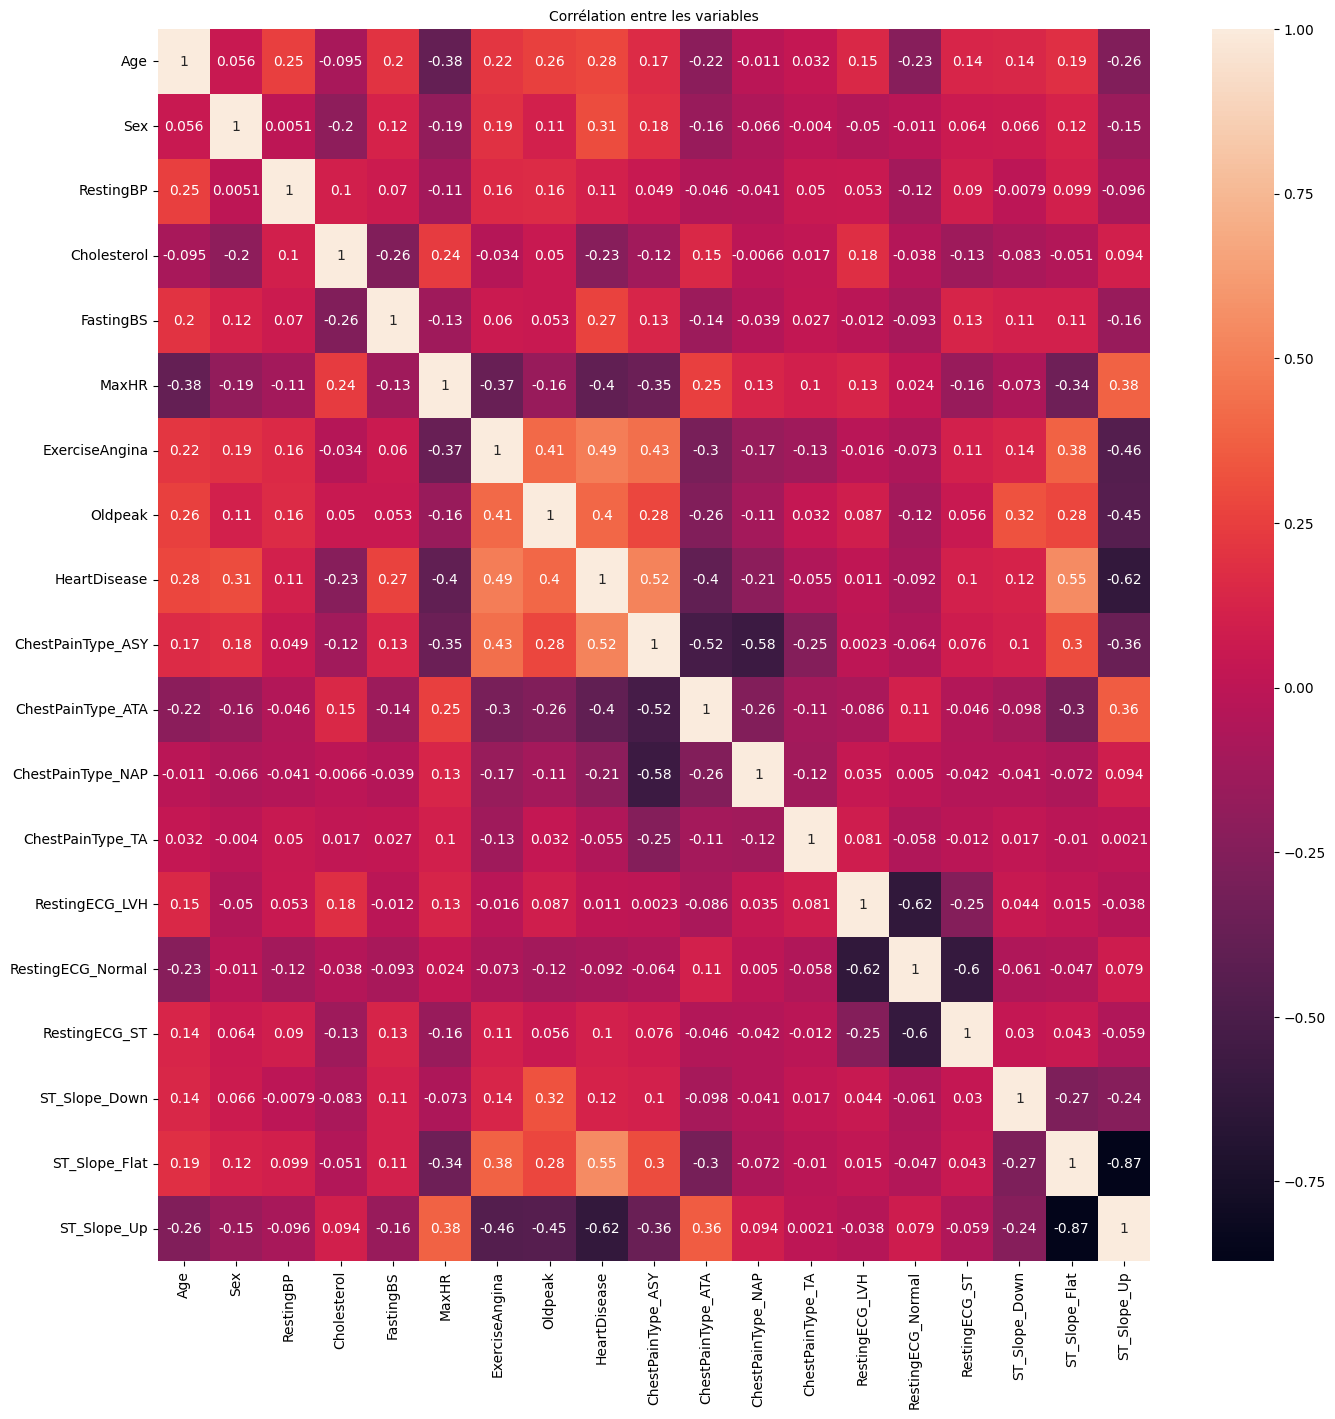

In [7]:
# Regardons si certaines features sont inutiles
print("Regardons si certaines features sont inutiles")


print()


plt.figure(figsize=(16, 16)) # Création d'une figure
sns.heatmap(df.corr(), annot=True) # Création d'une heatmap
plt.title("Corrélation entre les variables", size=10) # Titre de la heatmap
plt.show() # Affichage de la heatmap

In [8]:
# Suppression des features inutiles
print("Suppression des features inutiles")


print()


# Suppression des features inutiles (< 0.2) sauf Cholesterol
df = df.drop(["ChestPainType_TA",
    "RestingBP",
    "Cholesterol",
    "RestingECG_Normal",
    "RestingECG_LVH",
    "RestingECG_ST",
    "ST_Slope_Down"
    ],
    axis=1
)

# Création d'une liste contenant les noms des features restantes (>= 0.2) sauf Cholesterol
col_names = [
    "Age",
    "Sex",
    "ChestPainType_ASY",
    "ChestPainType_ATA",
    "ChestPainType_NAP",
    "FastingBS",
    "MaxHR",
    "ExerciseAngina",
    "Oldpeak",
    "ST_Slope_Flat",
    "ST_Slope_Up",
    "HeartDisease"
]

Suppression des features inutiles



---
# Entraînez des modèles ML pour prédire si les sujets étudiés ont une insuffisance cardiaque. Pour cela, vous devez suivre les étapes vues en cours et TD (train, test, optimisation des hyper-paramètres, métriques d’évaluation, etc...). Les modèles à considérer du cours : k-NN, forêts aléatoires, régression logistique, réseaux de neurones

Train/Test

In [9]:
# Train/Test
print("Train/Test")


print()


X = df.drop(["HeartDisease"], axis = 1).values # Séparation des features
y = df["HeartDisease"] # Séparation de la target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) # Séparation des données en train et test set (70/30) avec un random state de 42 pour la reproductibilité des résultats

Train/Test



Mise à l'échelle

In [10]:
# On met à l'échelle
print("On met à l'échelle")


print()


scaler = MinMaxScaler() # On instancie le MinMaxScaler
X_scaled = scaler.fit_transform(X) # On met à l'échelle les données du dataset complet
X_train_scaled = scaler.fit_transform(X_train) # On met à l'échelle les données du train set
X_test_scaled = scaler.transform(X_test) # On met à l'échelle les données du test set

On met à l'échelle



K-NN

In [11]:
# Algorithme K-NN
print("Algorithme K-NN")


print()


# Création des listes pour les métriques d'évaluation de l'algorithme K-NN (accuracy, precision, recall, f1_score) sur le train set et le test set (pour la comparaison finale)
accuracy_Knn_train = []
accuracy_Knn_test = []
precision_Knn_train = []
precision_Knn_test = []
recall_Knn_train = []
recall_Knn_test = []
f1_Knn_train = []
f1_Knn_test = []

k_lim = 51 # Maximum de K voisins à tester

Algorithme K-NN



Algorithme K-NN



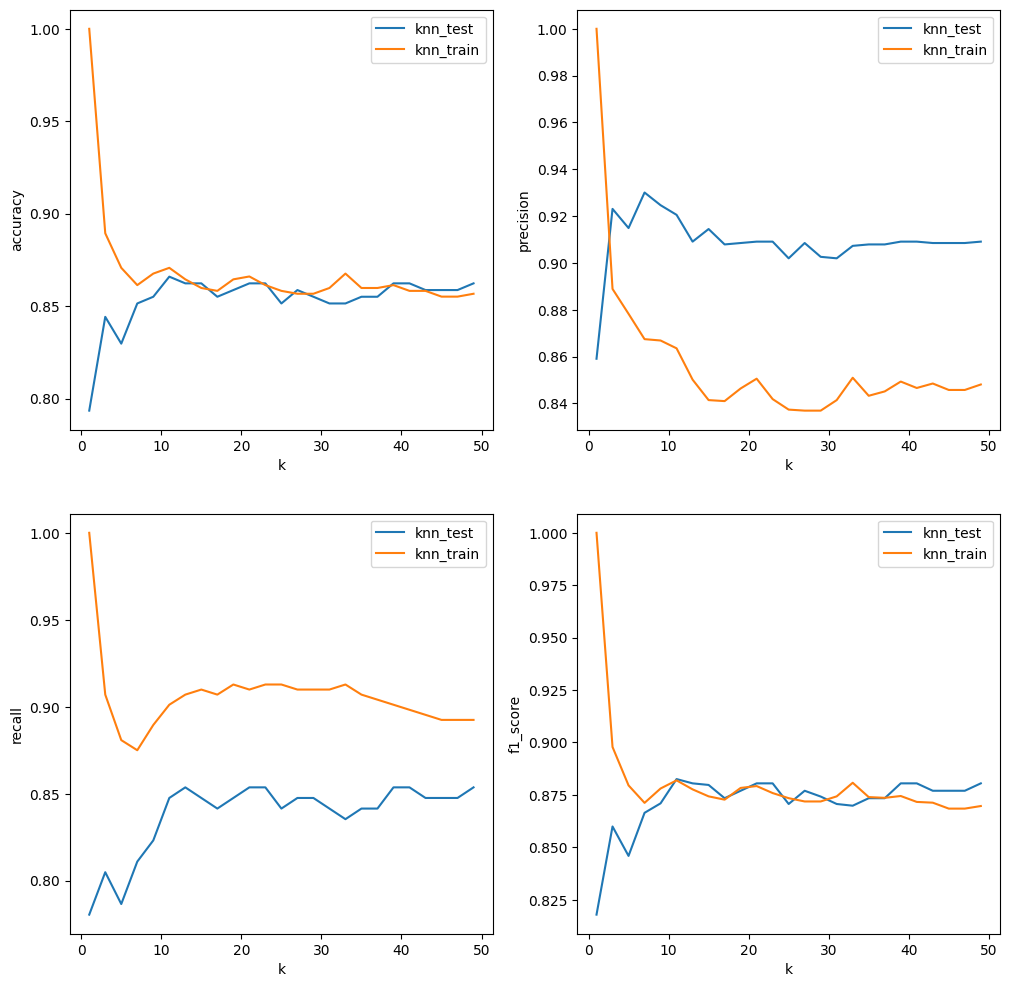

In [12]:
# Algorithme K-NN
print("Algorithme K-NN")


print()


# Boucle pour tester les différents K voisins (impairs) et calculer les métriques d'évaluation de l'algorithme K-NN (accuracy, precision, recall, f1_score) sur le train set et le test set (pour la comparaison finale)
for k in np.arange(1, k_lim, 2):
    # On instancie le KNeighborsClassifier avec un nombre de voisins égal à k et on entraîne le modèle sur le train set
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    # On prédit les valeurs du train set et du test set
    y_pred_train = knn.predict(X_train_scaled)
    y_pred_test = knn.predict(X_test_scaled)
    # On calcule les métriques d'évaluation de l'algorithme K-NN (accuracy, precision, recall, f1_score) sur le train set et le test set et on les ajoute aux listes correspondantes (pour la comparaison finale)
    accuracy_Knn_train.append(accuracy_score(y_train, y_pred_train))
    accuracy_Knn_test.append(accuracy_score(y_test, y_pred_test))
    precision_Knn_train.append(precision_score(y_train, y_pred_train))
    precision_Knn_test.append(precision_score(y_test, y_pred_test))
    recall_Knn_train.append(recall_score(y_train, y_pred_train))
    recall_Knn_test.append(recall_score(y_test, y_pred_test))
    f1_Knn_train.append(f1_score(y_train, y_pred_train))
    f1_Knn_test.append(f1_score(y_test, y_pred_test))

# Affichage des métriques d'évaluation de l'algorithme K-NN (accuracy, precision, recall, f1_score) sur le train set et le test set en fonction du nombre de voisins (impairs)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 12))
ax1.plot(np.arange(1, k_lim, 2), accuracy_Knn_test, label="knn_test")
ax1.plot(np.arange(1, k_lim, 2), accuracy_Knn_train, label="knn_train")
ax1.set_xlabel("k")
ax1.set_ylabel("accuracy")
ax1.legend()
#
ax2.plot(np.arange(1, k_lim, 2), precision_Knn_test, label="knn_test")
ax2.plot(np.arange(1, k_lim, 2), precision_Knn_train, label="knn_train")
ax2.set_xlabel("k")
ax2.set_ylabel("precision")
ax2.legend()
#
ax3.plot(np.arange(1, k_lim, 2), recall_Knn_test, label="knn_test")
ax3.plot(np.arange(1, k_lim, 2), recall_Knn_train, label="knn_train")
ax3.set_xlabel("k")
ax3.set_ylabel("recall")
ax3.legend()
#
ax4.plot(np.arange(1, k_lim, 2), f1_Knn_test, label="knn_test")
ax4.plot(np.arange(1, k_lim, 2), f1_Knn_train, label="knn_train")
ax4.set_xlabel("k")
ax4.set_ylabel("f1_score")
ax4.legend()
#
plt.show()

In [13]:
# Algorithme K-NN
print("Algorithme K-NN")


print()


# On cherche le meilleur K voisin (impair) pour l'algorithme K-NN en fonction de la métrique d'évaluation f1_score sur le test set
k_fin = 11 # Meilleur K voisin
knn_best = KNeighborsClassifier(n_neighbors=k_fin) # On instancie le KNeighborsClassifier avec le meilleur K voisin
knn_best.fit(X_train_scaled, y_train) # On entraîne le modèle sur le train set

# On prédit les valeurs du train set et du test set
y_pred_test = knn_best.predict(X_test_scaled)
y_pred_train = knn_best.predict(X_train_scaled)

# On calcule les métriques d'évaluation de l'algorithme K-NN (accuracy, precision, recall, f1_score) sur le train set et le test set avec le meilleur K voisin (impair) et on remplace les valeurs des listes correspondantes (pour la comparaison finale)
accuracy_Knn_test = accuracy_score(y_test, y_pred_test)
accuracy_Knn_train = accuracy_score(y_train, y_pred_train)
precision_Knn_test = precision_score(y_test, y_pred_test)
precision_Knn_train = precision_score(y_train, y_pred_train)
recall_Knn_test = recall_score(y_test, y_pred_test)
recall_Knn_train = recall_score(y_train, y_pred_train)
f1_Knn_test = f1_score(y_test, y_pred_test)
f1_Knn_train = f1_score(y_train, y_pred_train)

Algorithme K-NN



Random Forest

Algorithme Random Forest

{'n_estimators': [200, 400, 600, 800, 1000], 'max_depth': [10, 20, 30, 40, 50, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'bootstrap': [True, False]}
Fitting 3 folds for each of 540 candidates, totalling 1620 fits
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=400; total time=   0.3s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=400; total time=   0.3s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=400; total time=   0.3s
[CV] END bootstrap=True, max_d

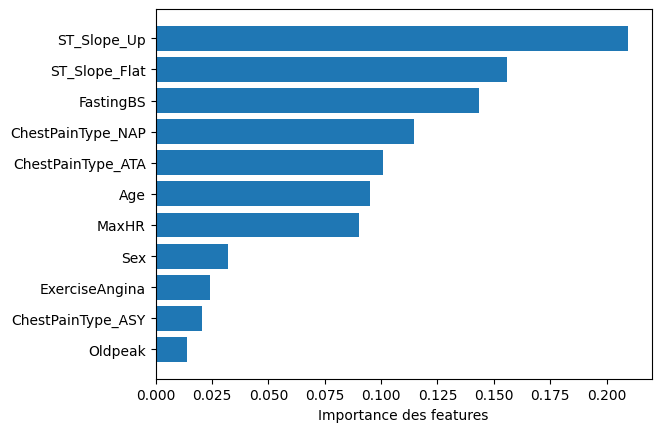

In [15]:
# Algorithme Random Forest
print("Algorithme Random Forest")


print()


# Parcours des possibilités (tester plus de valeurs possibles)
rf = RandomForestClassifier() # On instancie le RandomForestClassifier
n_estimators = [200, 400, 600, 800, 1000] # Nombre d'arbres dans la forêt aléatoire
max_depth = [10, 20, 30, 40, 50, None] # Nombre maximum de niveaux dans l'arbre
min_samples_split = [2, 5, 10] # Nombre minimum d'échantillons requis pour diviser un nœud
min_samples_leaf = [1, 2, 4] # Nombre minimum d'échantillons requis à chaque nœud feuille
bootstrap = [True, False] # Méthode de sélection des échantillons pour former chaque arbre

# Créer le param grid - dictionnaire
grid = {
    'n_estimators': n_estimators,
    'max_depth': max_depth,
    'min_samples_split': min_samples_split,
    'min_samples_leaf': min_samples_leaf,
    'bootstrap': bootstrap
}
print(grid)

# Recherche par validation croisée
grid_search = GridSearchCV(estimator=rf, verbose=2, param_grid=grid, cv=3, n_jobs=-1, scoring='f1') # On retient la métrique d'évaluation f1_score car elle est selon nous la plus pertinente pour ce problème
grid_search.fit(X_train_scaled, y_train) # On entraîne le modèle sur le train set

# On affiche les meilleurs paramètres, le meilleur estimateur et le meilleur score
meilleurs_parametres = grid_search.best_params_
rf_best = grid_search.best_estimator_
meilleur_score = grid_search.best_score_

# On affiche les meilleurs paramètres, le meilleur estimateur et le meilleur score
print("Meilleurs Paramètres :", meilleurs_parametres)
print("Meilleur Score en Validation Croisée :", meilleur_score)

# Tri des features par ordre d'importance, puis affichage des features avec un graphique
sorted_idx = rf_best.feature_importances_.argsort()
plt.barh([col_names[i] for i in sorted_idx], rf_best.feature_importances_[sorted_idx])
plt.xlabel("Importance des features")
plt.show()

In [19]:
# Algorithme Random Forest
print("Algorithme Random Forest")


print()


# Instanciation du RandomForestClassifier avec les meilleurs paramètres trouvés précédemment et entraînement du modèle sur le train set
rf_best = RandomForestClassifier(n_estimators=200, min_samples_split=10, min_samples_leaf=1, max_depth=40, bootstrap=True)
rf_best.fit(X_train_scaled, y_train)

# On prédit les valeurs du train set et du test set
y_pred_test = rf_best.predict(X_test_scaled)
y_pred_train = rf_best.predict(X_train_scaled)

# On calcule les métriques d'évaluation de l'algorithme Random Forest (accuracy, precision, recall, f1_score) sur le train set et le test set et on les ajoute aux listes correspondantes (pour la comparaison finale)
accuracy_rf_test = accuracy_score(y_test, y_pred_test)
accuracy_rf_train = accuracy_score(y_train, y_pred_train)
precision_rf_test = precision_score(y_test, y_pred_test)
precision_rf_train = precision_score(y_train, y_pred_train)
recall_rf_test = recall_score(y_test, y_pred_test)
recall_rf_train = recall_score(y_train, y_pred_train)
f1_rf_test = f1_score(y_test, y_pred_test)
f1_rf_train = f1_score(y_train, y_pred_train)

Algorithme Random Forest



Régression logistique

In [20]:
# Algorithme de régression logistique
print("Algorithme de régression logistique")


print()


# Création des listes pour les métriques d'évaluation de l'algorithme de régression logistique (accuracy, precision, recall, f1_score) sur le train set et le test set (pour la comparaison finale)
accuracy_LR_train = []
accuracy_LR_test = []
precision_LR_train = []
precision_LR_test = []
recall_LR_train = []
recall_LR_test = []
f1_LR_train = []
f1_LR_test = []

d_lim = 8  # Maximum de degrés à tester (testé jusqu'à 10, mais ça prend trop de temps)

Algorithme de régression logistique



Algorithme de régression logistique



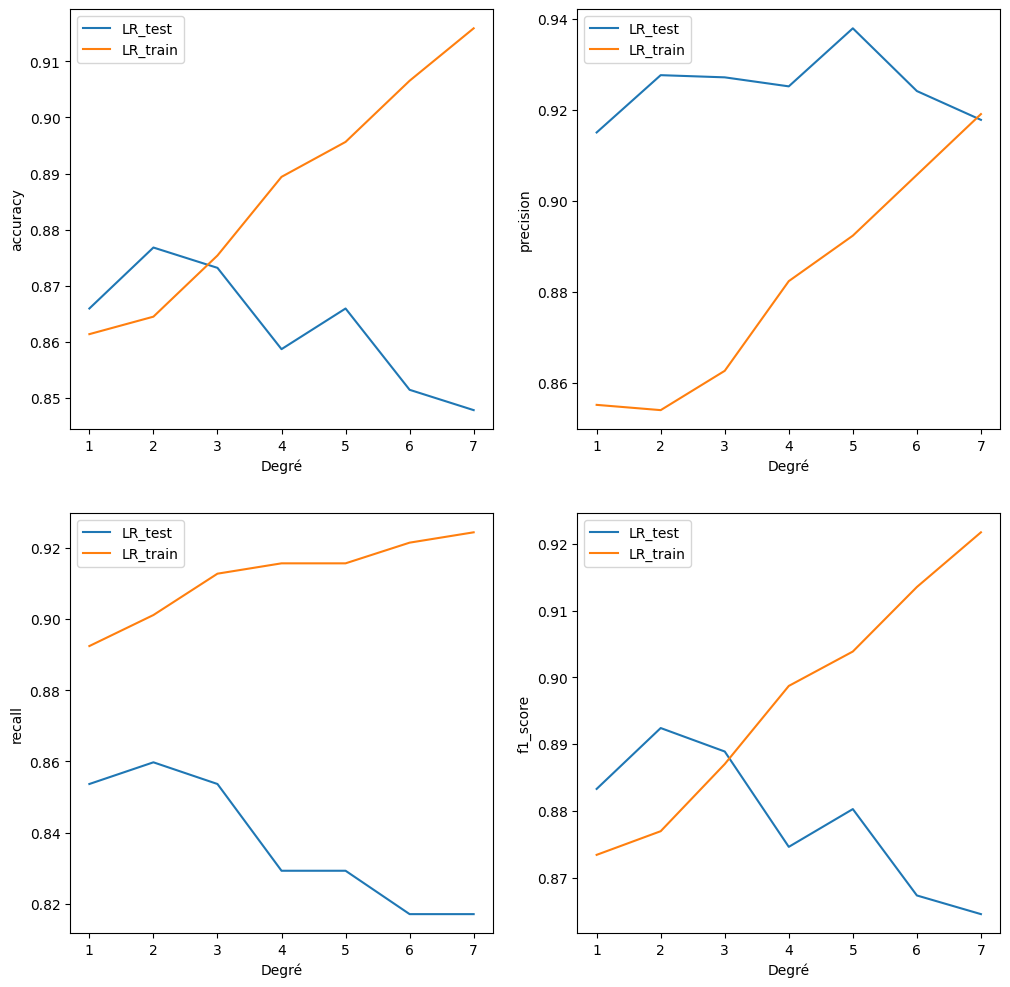

In [21]:
# Algorithme de régression logistique
print("Algorithme de régression logistique")


print()

# Boucle pour tester les différents degrés et calculer les métriques d'évaluation de l'algorithme de régression logistique (accuracy, precision, recall, f1_score) sur le train set et le test set (pour la comparaison finale)
for d in range(1, d_lim):
    # On instancie le PolynomialFeatures avec un degré égal à d
    poly = PolynomialFeatures(degree=d)
    # On met à l'échelle les données du train set et du test set
    X_poly_train_scaled = poly.fit_transform(X_train_scaled)
    X_poly_test_scaled = poly.transform(X_test_scaled)
    # On instancie le LogisticRegression et on entraîne le modèle sur le train set
    LR_model = LogisticRegression(penalty='l2', C=1, max_iter=2000)  # penalty = None testé mais mauvais sur test
    LR_model.fit(X_poly_train_scaled, y_train)
    # On prédit les valeurs du train set et du test set
    y_pred_test = LR_model.predict(X_poly_test_scaled)
    y_pred_train = LR_model.predict(X_poly_train_scaled)
    # On calcule les métriques d'évaluation de l'algorithme de régression logistique (accuracy, precision, recall, f1_score) sur le train set et le test set et on les ajoute aux listes correspondantes (pour la comparaison finale)
    accuracy_LR_test.append(accuracy_score(y_test, y_pred_test))
    accuracy_LR_train.append(accuracy_score(y_train, y_pred_train))
    precision_LR_test.append(precision_score(y_test, y_pred_test))
    precision_LR_train.append(precision_score(y_train, y_pred_train))
    recall_LR_test.append(recall_score(y_test, y_pred_test))
    recall_LR_train.append(recall_score(y_train, y_pred_train))
    f1_LR_test.append(f1_score(y_test, y_pred_test))
    f1_LR_train.append(f1_score(y_train, y_pred_train))

# Affichage des métriques d'évaluation de l'algorithme de régression logistique (accuracy, precision, recall, f1_score) sur le train set et le test set en fonction du degré
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 12))
ax1.plot(range(1, d_lim), accuracy_LR_test, label="LR_test")
ax1.plot(range(1, d_lim), accuracy_LR_train, label="LR_train")
ax1.set_xlabel("Degré")
ax1.set_ylabel("accuracy")
ax1.legend()
#
ax2.plot(range(1, d_lim), precision_LR_test, label="LR_test")
ax2.plot(range(1, d_lim), precision_LR_train, label="LR_train")
ax2.set_xlabel("Degré")
ax2.set_ylabel("precision")
ax2.legend()
#
ax3.plot(range(1, d_lim), recall_LR_test, label="LR_test")
ax3.plot(range(1, d_lim), recall_LR_train, label="LR_train")
ax3.set_xlabel("Degré")
ax3.set_ylabel("recall")
ax3.legend()
#
ax4.plot(range(1, d_lim), f1_LR_test, label="LR_test")
ax4.plot(range(1, d_lim), f1_LR_train, label="LR_train")
ax4.set_xlabel("Degré")
ax4.set_ylabel("f1_score")
ax4.legend()
#
plt.show()

Algorithme de régression logistique



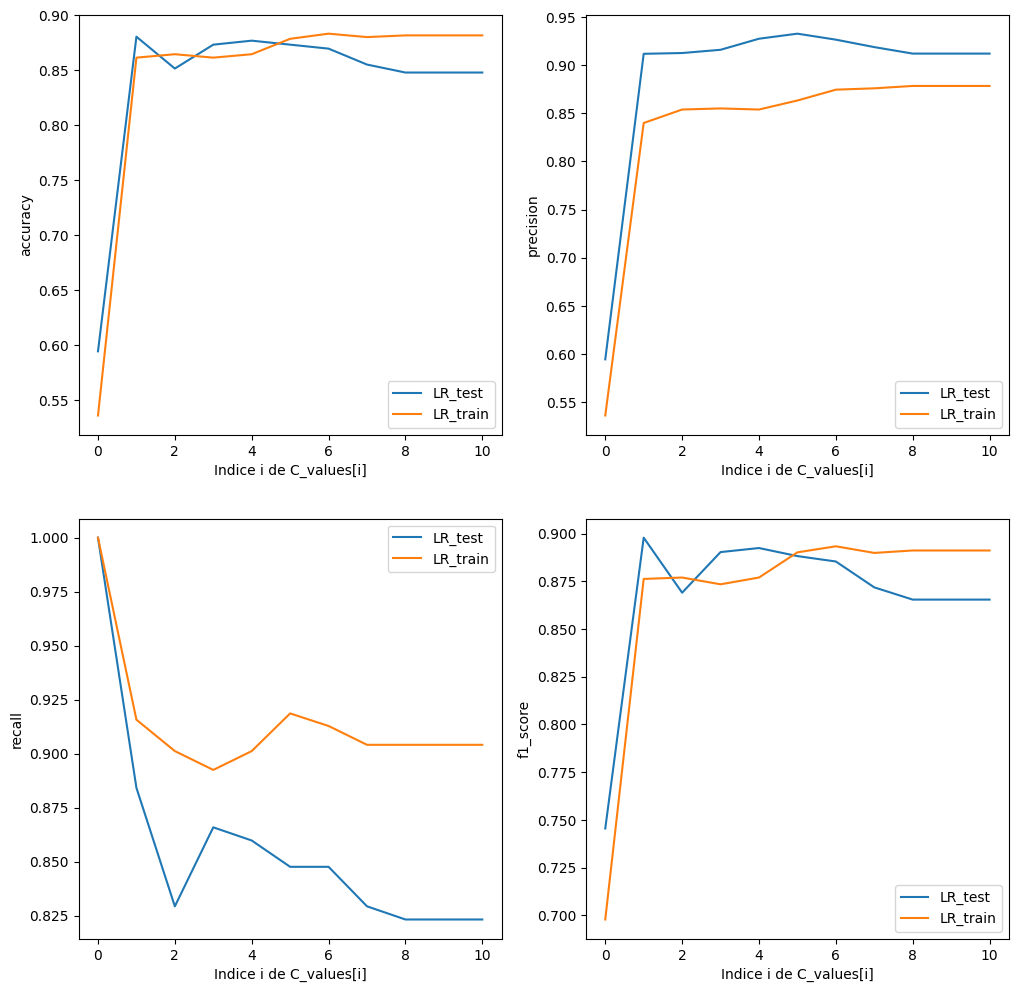

In [22]:
# Algorithme de régression logistique
print("Algorithme de régression logistique")


print()


d_fin = 2 # Meilleur degré trouvé

# On instancie le PolynomialFeatures avec le meilleur degré
poly = PolynomialFeatures(degree=d_fin)

# On met à l'échelle les données du train set et du test set
X_poly_train_scaled = poly.fit_transform(X_train_scaled)
X_poly_test_scaled = poly.transform(X_test_scaled)

# Testons maintenant la variation sur c
C_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10e4, 10e6, 10e9]

# Réinitialisation des listes pour les métriques d'évaluation de l'algorithme de régression logistique (accuracy, precision, recall, f1_score) sur le train set et le test set (pour la comparaison finale)
accuracy_LR_train = []
accuracy_LR_test = []
precision_LR_train = []
precision_LR_test = []
recall_LR_train = []
recall_LR_test = []
f1_LR_train = []
f1_LR_test = []

# Boucle pour tester les différents C et calculer les métriques d'évaluation de l'algorithme de régression logistique (accuracy, precision, recall, f1_score) sur le train set et le test set (pour la comparaison finale)
for c in C_values:
    # On instancie le LogisticRegression avec un C égal à c et on entraîne le modèle sur le train set
    LR_model = LogisticRegression(penalty='l2', C=c, max_iter=2000)
    LR_model.fit(X_poly_train_scaled, y_train)
    # On prédit les valeurs du train set et du test set
    y_pred_test = LR_model.predict(X_poly_test_scaled)
    y_pred_train = LR_model.predict(X_poly_train_scaled)
    # On calcule les métriques d'évaluation de l'algorithme de régression logistique (accuracy, precision, recall, f1_score) sur le train set et le test set et on les ajoute aux listes correspondantes (pour la comparaison finale)
    accuracy_LR_test.append(accuracy_score(y_test, y_pred_test))
    accuracy_LR_train.append(accuracy_score(y_train, y_pred_train))
    precision_LR_test.append(precision_score(y_test, y_pred_test))
    precision_LR_train.append(precision_score(y_train, y_pred_train))
    recall_LR_test.append(recall_score(y_test, y_pred_test))
    recall_LR_train.append(recall_score(y_train, y_pred_train))
    f1_LR_test.append(f1_score(y_test, y_pred_test))
    f1_LR_train.append(f1_score(y_train, y_pred_train))

# Affichage des métriques d'évaluation de l'algorithme de régression logistique (accuracy, precision, recall, f1_score) sur le train set et le test set en fonction de C
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 12))
ax1.plot(range(len(C_values)), accuracy_LR_test, label="LR_test")
ax1.plot(range(len(C_values)), accuracy_LR_train, label="LR_train")
ax1.set_xlabel("Indice i de C_values[i]")
ax1.set_ylabel("accuracy")
ax1.legend()
#
ax2.plot(range(len(C_values)), precision_LR_test, label="LR_test")
ax2.plot(range(len(C_values)), precision_LR_train, label="LR_train")
ax2.set_xlabel("Indice i de C_values[i]")
ax2.set_ylabel("precision")
ax2.legend()
#
ax3.plot(range(len(C_values)), recall_LR_test, label="LR_test")
ax3.plot(range(len(C_values)), recall_LR_train, label="LR_train")
ax3.set_xlabel("Indice i de C_values[i]")
ax3.set_ylabel("recall")
ax3.legend()
#
ax4.plot(range(len(C_values)), f1_LR_test, label="LR_test")
ax4.plot(range(len(C_values)), f1_LR_train, label="LR_train")
ax4.set_xlabel("Indice i de C_values[i]")
ax4.set_ylabel("f1_score")
ax4.legend()
#
plt.show()

In [23]:
# Algorithme de régression logistique
print("Algorithme de régression logistique")


print()


c_fin = 1 # Meilleur C trouvé

# On instancie le LogisticRegression avec le meilleur C et on entraîne le modèle sur le train set
LR_best = LogisticRegression(penalty='l2', C=1, max_iter=2000)
LR_best.fit(X_poly_train_scaled, y_train)

# On prédit les valeurs du train set et du test set
y_pred_test = LR_best.predict(X_poly_test_scaled)
y_pred_train = LR_best.predict(X_poly_train_scaled)


# On calcule les métriques d'évaluation de l'algorithme de régression logistique (accuracy, precision, recall, f1_score) sur le train set et le test set avec le meilleur C et on remplace les valeurs des listes correspondantes (pour la comparaison finale)
accuracy_LR_test = accuracy_score(y_test, y_pred_test)
accuracy_LR_train = accuracy_score(y_train, y_pred_train)
precision_LR_test = precision_score(y_test, y_pred_test)
precision_LR_train = precision_score(y_train, y_pred_train)
recall_LR_test = recall_score(y_test, y_pred_test)
recall_LR_train = recall_score(y_train, y_pred_train)
f1_LR_test = f1_score(y_test, y_pred_test)
f1_LR_train = f1_score(y_train, y_pred_train)

Algorithme de régression logistique



Réseau de neurones

In [24]:
# Algorithme de réseau de neurones
print("Algorithme de réseau de neurones")


print()


n_cols = X_scaled.shape[1] # Nombre de features
optimizer = Adam(learning_rate=0.001) # On instancie l'optimizer Adam avec un learning rate de 0.001

# Recherche avec GridSearchCV d'un bon modèle modèle

# On définit une fonction pour générer nos modèles
def create_Node_model(activation, neurons_per_layer):
    # activation est un str
    # neurons_per_layer est une liste contenant le nombre de neuronnes par couches, en excluant la dernière
    Node_model = Sequential()
    Node_model.add(Input(shape=(n_cols, )))
    for nb_node in neurons_per_layer:
        Node_model.add(Dense(units=nb_node, activation=activation))
    Node_model.add(Dense(units=1, activation='sigmoid'))
    return Node_model

# On instancie EarlyStopping pour éviter le surapprentissage
early_stopping_monitor = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# On instancie le KerasClassifier avec la fonction de création de modèle, les paramètres à tester et les paramètres de compilation
Node_model = KerasClassifier(model = create_Node_model, activation = "relu", neurons_per_layer = (10, ), validation_split=0.3, epochs = 10, optimizer=optimizer, loss='binary_crossentropy', verbose=2, random_state=42, callbacks=[early_stopping_monitor])

# Différentes fonctions d'activation
activation = [
    "relu",
    "elu",
    "tanh"
]

# Différentes structures de réseaux
neurons_per_layer = [
    (10, ),
    (10, 5, ),
    (20, ),
    (20, 5, ),
    (50, 10, ),
    (50, 20, 5, ),
    (100, 10, ),
    (100, 25, 5, ),
    (200, 50, 10, ),
    (500, 100, 25, 5, ),
    (918, ),
    (918, 918, ),
    (918, 918, 918, ),
    (918, 300, 300, ),
    (918, 300, 300, 300, ),
    (918, 230, 230, ),
    (918, 450, ),
    (918, ),
    (918, 300, ),
    (918, 450, 450, ),
    (918, 230, 230, 230, 230, ),
    (918, 450, 220, 100, 50, )
]

# Créer le param grid - dictionnaire
grid = {
    'activation': activation,
    'neurons_per_layer': neurons_per_layer
}

# Recherche par validation croisée
grid_search = GridSearchCV(estimator=Node_model, verbose=2, param_grid=grid, cv=3, n_jobs=-1, scoring='f1')

# Entraînement du modèle sur le train set
grid_search.fit(X_scaled, y)

# On affiche les meilleurs paramètres, le meilleur estimateur et le meilleur score
meilleurs_parametres = grid_search.best_params_
meilleur_score = grid_search.best_score_
print("Meilleurs Paramètres :", meilleurs_parametres)
print("Meilleur Score en Validation Croisée :", meilleur_score)

Algorithme de réseau de neurones

Fitting 3 folds for each of 66 candidates, totalling 198 fits


2023-12-13 23:19:49.003474: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2023-12-13 23:19:49.003495: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2023-12-13 23:19:49.003500: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2023-12-13 23:19:49.003546: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-12-13 23:19:49.003579: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2023-12-13 23:19:49.139539: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2023-12-13 23:19:49.139560: I metal_plugin/src/device/metal_device.cc:296] syste

Epoch 1/10
Epoch 1/10
Epoch 1/10
Epoch 1/10
Epoch 1/10
Epoch 1/10
Epoch 1/10
Epoch 1/10


2023-12-13 23:19:50.417662: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2023-12-13 23:19:50.472963: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2023-12-13 23:19:50.541680: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2023-12-13 23:19:50.555740: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2023-12-13 23:19:50.558790: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2023-12-13 23:19:50.572025: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2023-12-13 23:19:50.600819: I tensorflow/core/grappler/optimizers/cust

14/14 - 5s - loss: 0.7074 - val_loss: 0.6762 - 5s/epoch - 331ms/step
Epoch 2/10
14/14 - 5s - loss: 0.7264 - val_loss: 0.6766 - 5s/epoch - 335ms/step
Epoch 2/10
14/14 - 5s - loss: 0.6903 - val_loss: 0.6645 - 5s/epoch - 338ms/step
Epoch 2/10
14/14 - 0s - loss: 0.6511 - val_loss: 0.6501 - 242ms/epoch - 17ms/step
Epoch 3/10
14/14 - 5s - loss: 0.7022 - val_loss: 0.6541 - 5s/epoch - 362ms/step
14/14 - 5s - loss: 0.7101 - val_loss: 0.6558 - 5s/epoch - 347ms/step
Epoch 2/10
Epoch 2/10
14/14 - 0s - loss: 0.6730 - val_loss: 0.6515 - 264ms/epoch - 19ms/step
14/14 - 0s - loss: 0.6440 - val_loss: 0.6193 - 253ms/epoch - 18ms/step
Epoch 3/10
Epoch 3/10
14/14 - 0s - loss: 0.6076 - val_loss: 0.6317 - 259ms/epoch - 18ms/step
Epoch 4/10
14/14 - 0s - loss: 0.6558 - val_loss: 0.6310 - 205ms/epoch - 15ms/step
Epoch 3/10
14/14 - 0s - loss: 0.6426 - val_loss: 0.6290 - 249ms/epoch - 18ms/step
Epoch 3/10
14/14 - 0s - loss: 0.6055 - val_loss: 0.5826 - 233ms/epoch - 17ms/step
Epoch 4/10
14/14 - 0s - loss: 0.5743 

...

14/14 - 2s - loss: 0.7920 - val_loss: 0.6222 - 2s/epoch - 163ms/step
Epoch 2/10
14/14 - 0s - loss: 0.5834 - val_loss: 0.6689 - 239ms/epoch - 17ms/step
Epoch 5/10
Epoch 1/10
14/14 - 0s - loss: 0.5899 - val_loss: 0.6053 - 261ms/epoch - 19ms/step
Epoch 3/10
14/14 - 0s - loss: 0.5283 - val_loss: 0.6609 - 255ms/epoch - 18ms/step
Epoch 6/10
14/14 - 0s - loss: 0.5599 - val_loss: 0.6565 - 257ms/epoch - 18ms/step
Epoch 6/10
14/14 - 0s - loss: 0.6011 - val_loss: 0.5674 - 291ms/epoch - 21ms/step
Epoch 3/10
14/14 - 2s - loss: 0.8007 - val_loss: 0.6278 - 2s/epoch - 153ms/step
Epoch 2/10
14/14 - 0s - loss: 0.5471 - val_loss: 0.5741 - 257ms/epoch - 18ms/step
Epoch 4/10
14/14 - 0s - loss: 0.4953 - val_loss: 0.6530 - 283ms/epoch - 20ms/step
Epoch 7/10
14/14 - 0s - loss: 0.5326 - val_loss: 0.6442 - 223ms/epoch - 16ms/step
Epoch 7/10
14/14 - 0s - loss: 0.5250 - val_loss: 0.5324 - 222ms/epoch - 16ms/step
Epoch 4/10
14/14 - 0s - loss: 0.5099 - val_loss: 0.5495 - 262ms/epoch - 19ms/step
Epoch 5/10
14/14 - 0

2023-12-13 23:21:35.654521: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2023-12-13 23:21:35.654609: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2023-12-13 23:21:35.654623: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2023-12-13 23:21:35.654854: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-12-13 23:21:35.654883: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/10


2023-12-13 23:21:36.650565: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


21/21 - 4s - loss: 0.4516 - val_loss: 0.4799 - 4s/epoch - 176ms/step
Epoch 2/10
21/21 - 0s - loss: 0.3089 - val_loss: 0.5197 - 131ms/epoch - 6ms/step
Epoch 3/10
21/21 - 0s - loss: 0.2991 - val_loss: 0.5306 - 127ms/epoch - 6ms/step
Meilleurs Paramètres : {'activation': 'tanh', 'neurons_per_layer': (918,)}
Meilleur Score en Validation Croisée : 0.8817946304805884


In [25]:
# Algorithme de réseau de neurones
print("Algorithme de réseau de neurones")


print()


optimizer = Adam(learning_rate=0.001) # On instancie l'optimizer Adam avec un learning rate de 0.001

# On instancie EarlyStopping pour éviter le surapprentissage
early_stopping_monitor = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# On instancie le KerasClassifier avec les meilleurs paramètres trouvés précédemment et on entraîne le modèle sur le train set
Node_best = KerasClassifier(model=create_Node_model, activation="tanh", neurons_per_layer=(918, ), validation_split=0.3, epochs=10, optimizer=optimizer, loss='binary_crossentropy', verbose=2, random_state=42, callbacks=[early_stopping_monitor])
Node_best.fit(X_scaled, y)

# Prédiction sur le train set et le test set
y_test_proba = Node_best.predict(X_test_scaled)
y_pred_test = (y_test_proba >= 0.5).astype(int)
y_train_proba = Node_best.predict(X_train_scaled)
y_pred_train = (y_train_proba >= 0.5).astype(int)

# On calcule les métriques d'évaluation de l'algorithme de réseau de neurones (accuracy, precision, recall, f1_score) sur le train set et le test set et on les ajoute aux listes correspondantes (pour la comparaison finale)
accuracy_Node_test = accuracy_score(y_test, y_pred_test)
accuracy_Node_train = accuracy_score(y_train, y_pred_train)
precision_Node_test = precision_score(y_test, y_pred_test)
precision_Node_train = precision_score(y_train, y_pred_train)
recall_Node_test = recall_score(y_test, y_pred_test)
recall_Node_train = recall_score(y_train, y_pred_train)
f1_Node_test = f1_score(y_test, y_pred_test)
f1_Node_train = f1_score(y_train, y_pred_train)

Algorithme de réseau de neurones

Epoch 1/10
21/21 - 1s - loss: 0.4516 - val_loss: 0.4799 - 507ms/epoch - 24ms/step
Epoch 2/10
21/21 - 0s - loss: 0.3089 - val_loss: 0.5197 - 133ms/epoch - 6ms/step
Epoch 3/10
21/21 - 0s - loss: 0.2991 - val_loss: 0.5306 - 128ms/epoch - 6ms/step
9/9 - 0s - 95ms/epoch - 11ms/step
21/21 - 0s - 63ms/epoch - 3ms/step


---
# Choisissez un algorithme de classification non vu en cours. Expliquez-le brièvement et faites l’implémentation python.

In [26]:
# Algorithmes de SVC
print("Algorithmes de SVC")


print()


# Création de la liste des paramètres à tester pour le SVC (C, kernel, gamma)
param_grid = {
    'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10e4, 10e6, 10e9], # Paramètre de régularisation (C) : plus C est grand, plus la régularisation est faible
    'kernel': ['linear', 'rbf', 'poly'], # Type de noyau (kernel) : linéaire, gaussien ou polynomial
    'gamma': ['scale', 'auto'] # Coefficient du noyau pour 'rbf' et 'poly' : 'scale' = 1 / (n_features * X.var()) ; 'auto' = 1 / n_features
}

# Recherche par validation croisée et entraînement du modèle sur le train set
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2, cv=3, n_jobs=-1, scoring='f1')
grid.fit(X_train_scaled, y_train)

# On affiche les meilleurs paramètres, le meilleur estimateur et le meilleur score
meilleurs_parametres = grid.best_params_
meilleur_score = grid.best_score_
print("Meilleurs Paramètres :", meilleurs_parametres)
print("Meilleur Score en Validation Croisée :", meilleur_score)

Algorithmes de SVC

Fitting 3 folds for each of 66 candidates, totalling 198 fits
[CV] END ...............C=0.0001, gamma=scale, kernel=linear; total time=   0.0s
[CV] END .................C=0.0001, gamma=scale, kernel=poly; total time=   0.0s
[CV] END ...............C=0.0001, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ................C=0.0001, gamma=auto, kernel=linear; total time=   0.0s
[CV] END ...............C=0.0001, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ................C=0.0001, gamma=auto, kernel=linear; total time=   0.0s
[CV] END ................C=0.0001, gamma=auto, kernel=linear; total time=   0.0s
[CV] END ..................C=0.0001, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END ..................C=0.0001, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END ...................C=0.0001, gamma=auto, kernel=rbf; total time=   0.0s
[CV] END ...................C=0.0001, gamma=auto, kernel=rbf; total time=   0.0s
[CV] END ..................

In [28]:
# Algorithmes de SVC
print("Algorithmes de SVC")


print()


# On instancie le SVC avec les meilleurs paramètres trouvés précédemment et on entraîne le modèle sur le train set
SVC_best = SVC(C=100000.0, gamma='scale', kernel='linear')
SVC_best.fit(X_train_scaled, y_train)

# Prédiction sur le train set et le test set
y_test_proba = SVC_best.predict(X_test_scaled)
y_pred_test = (y_test_proba >= 0.5).astype(int)
y_train_proba = SVC_best.predict(X_train_scaled)
y_pred_train = (y_train_proba >= 0.5).astype(int)

# Pour la comparaison final
accuracy_SVC_test = accuracy_score(y_test, y_pred_test)
accuracy_SVC_train = accuracy_score(y_train, y_pred_train)
precision_SVC_test = precision_score(y_test, y_pred_test)
precision_SVC_train = precision_score(y_train, y_pred_train)
recall_SVC_test = recall_score(y_test, y_pred_test)
recall_SVC_train = recall_score(y_train, y_pred_train)
f1_SVC_test = f1_score(y_test, y_pred_test)
f1_SVC_train = f1_score(y_train, y_pred_train)

Algorithmes de SVC



---
# Comparer tous les résultats obtenus (au total, vous allez tester 5 algorithmes)

Comparaison finale des différents algorithmes



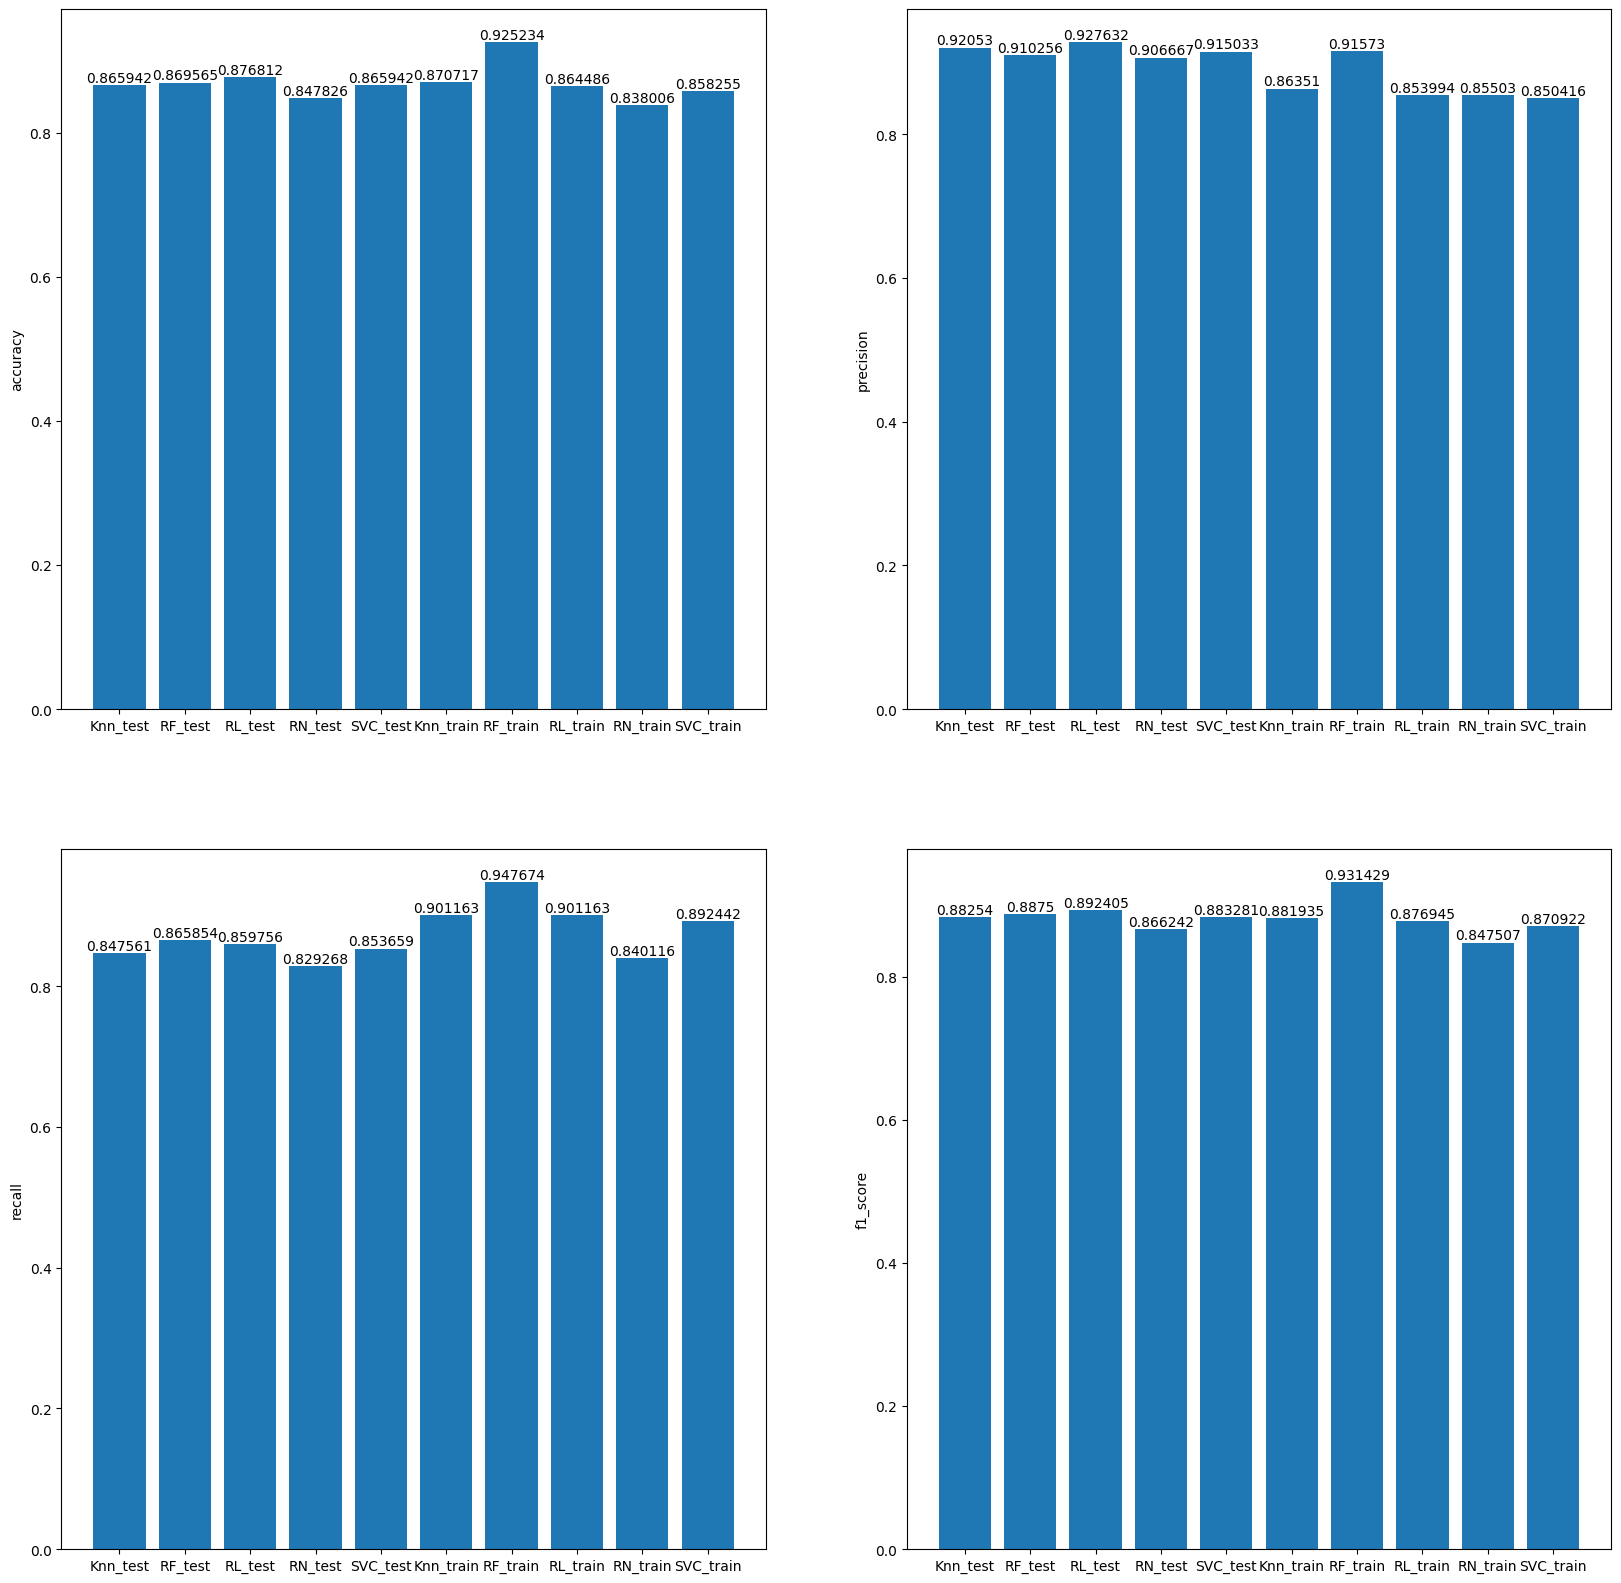

In [29]:
# Comparaison finale des différents algorithmes
print("Comparaison finale des différents algorithmes")


print()


# Algorithmes
algos = ["Knn_test", "RF_test", "RL_test", "RN_test", "SVC_test", "Knn_train", "RF_train", "RL_train", "RN_train", "SVC_train"]

# Métriques d'évaluation sur le test set
accuracy_algo_test = [accuracy_Knn_test, accuracy_rf_test, accuracy_LR_test, accuracy_Node_test, accuracy_SVC_test]
precision_algo_test = [precision_Knn_test, precision_rf_test, precision_LR_test, precision_Node_test, precision_SVC_test]
recall_algo_test = [recall_Knn_test, recall_rf_test, recall_LR_test, recall_Node_test, recall_SVC_test]
f1_algo_test = [f1_Knn_test, f1_rf_test, f1_LR_test, f1_Node_test, f1_SVC_test]

# Métriques d'évaluation sur le train set
accuracy_algo_train = [accuracy_Knn_train, accuracy_rf_train, accuracy_LR_train, accuracy_Node_train, accuracy_SVC_train]
precision_algo_train = [precision_Knn_train, precision_rf_train, precision_LR_train, precision_Node_train, precision_SVC_train]
recall_algo_train = [recall_Knn_train, recall_rf_train, recall_LR_train, recall_Node_train, recall_SVC_train]
f1_algo_train = [f1_Knn_train, f1_rf_train, f1_LR_train, f1_Node_train, f1_SVC_train]

# Affichage des métriques d'évaluation des différents algorithmes sur le test set et le train set
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 20))
rect1 = ax1.bar(algos, accuracy_algo_test + accuracy_algo_train)
ax1.bar_label(rect1)
ax1.set_ylabel("accuracy")
#
rect2 = ax2.bar(algos, precision_algo_test + precision_algo_train)
ax2.bar_label(rect2)
ax2.set_ylabel("precision")
#
rect3 = ax3.bar(algos, recall_algo_test + recall_algo_train)
ax3.bar_label(rect3)
ax3.set_ylabel("recall")
#
rect4 = ax4.bar(algos, f1_algo_test + f1_algo_train)
ax4.bar_label(rect4)
ax4.set_ylabel("f1_score")
#
plt.show()

---